<a href="https://colab.research.google.com/github/broistg/ML-Assignment-DNAC1/blob/main/notebooks/BTL_Extra_HMM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0.&nbsp;User manual

This Google Colab file implements three Hidden Markov Model (HMM) algorithms - which are Forward, Viterbi, and Baum-Welch - for the TIMIT dataset (sound data). To run the entire workflow, simply click Run All (library installation and dataset loading are automated).

# 1.&nbsp;Prepare the necessary data and libraries

## 1.1.&nbsp;Verify and install necessary libraries

In [ ]:
# Verify required libraries
import sys
import subprocess

def pip_install(packages):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet"] + packages)

pip_install(["scikit-learn", "pandas", "matplotlib", "seaborn", "torch", "torchaudio", "librosa"])

# Import libraries
import os
import glob
import random
import json
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_files
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, classification_report, confusion_matrix
import torch
import librosa
import librosa.display
import kagglehub
from tqdm.notebook import tqdm
from scipy.io import wavfile
from scipy.special import logsumexp
from collections import defaultdict
import pickle
import joblib
from huggingface_hub import hf_hub_download, HfApi

# For widgets
import ipywidgets as widgets
from IPython.display import display, clear_output

# Utilities
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", DEVICE)

# Ensure reproducibility
RND = 42
random.seed(RND); np.random.seed(RND); torch.manual_seed(RND)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RND)

ROOT = Path('.').absolute()
FEATURE_ROOT = ROOT / 'features'
FEATURE_ROOT.mkdir(exist_ok=True)

REPO_ID = 'LeTienDat/TIMIT-Phoneme'

Device: cpu


## 1.2.&nbsp;Download and store the dataset

In [ ]:
# Download latest version
timit_path = kagglehub.dataset_download("mfekadu/darpa-timit-acousticphonetic-continuous-speech")
data_path = timit_path + "/data"

print("Path to dataset:", timit_path)
print("Path to data:", data_path)

Using Colab cache for faster access to the 'darpa-timit-acousticphonetic-continuous-speech' dataset.
Path to dataset: /kaggle/input/darpa-timit-acousticphonetic-continuous-speech
Path to data: /kaggle/input/darpa-timit-acousticphonetic-continuous-speech/data


In [ ]:
# Collect all .wav files
timit_wav_files = []
if os.path.exists(data_path):
    for root, dirs, files in os.walk(data_path):
        for file in files:
            if file.endswith('.WAV'):
                timit_wav_files.append(os.path.join(root, file))
else:
    print(f"TIMIT directory not found at {data_path} after attempted download/extraction.")
    print("Please ensure the dataset is downloaded and extracted to this location manually.")

print("Number of .wav files:", len(timit_wav_files))

Number of .wav files: 6300


# 2.&nbsp;Exploratory Data Analysis (EDA)

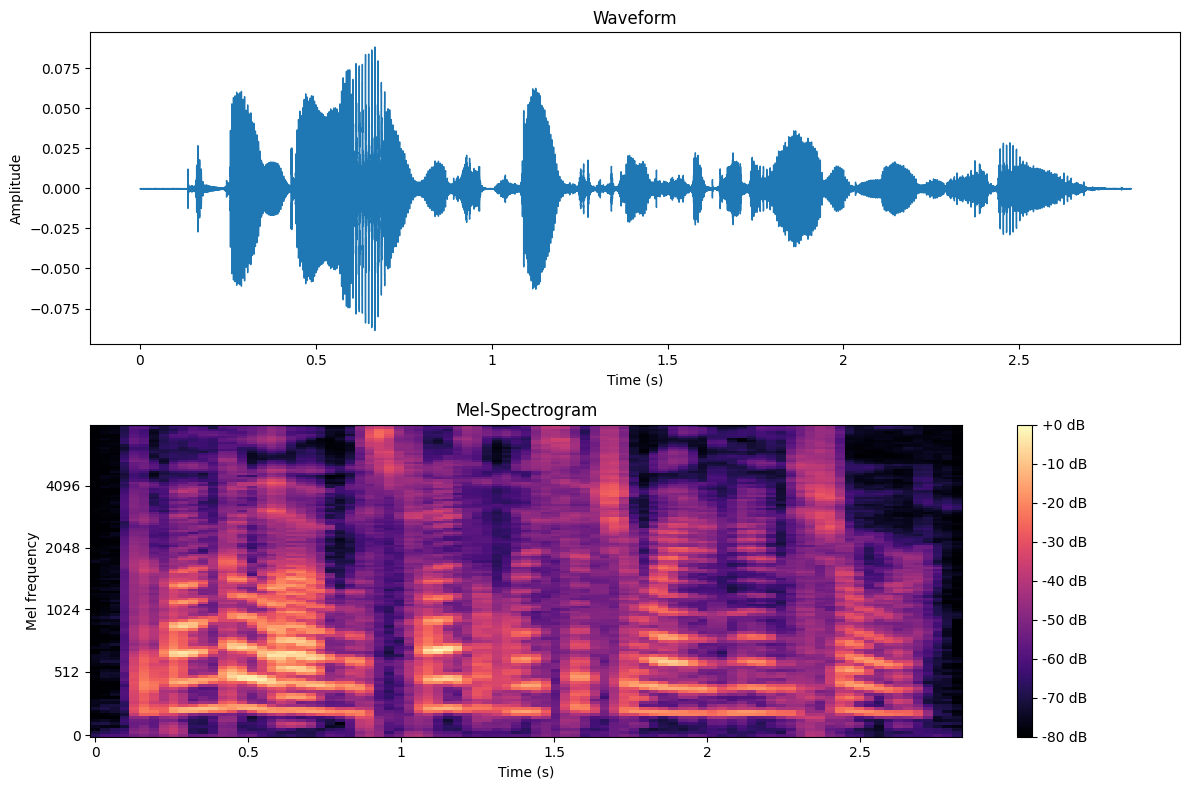

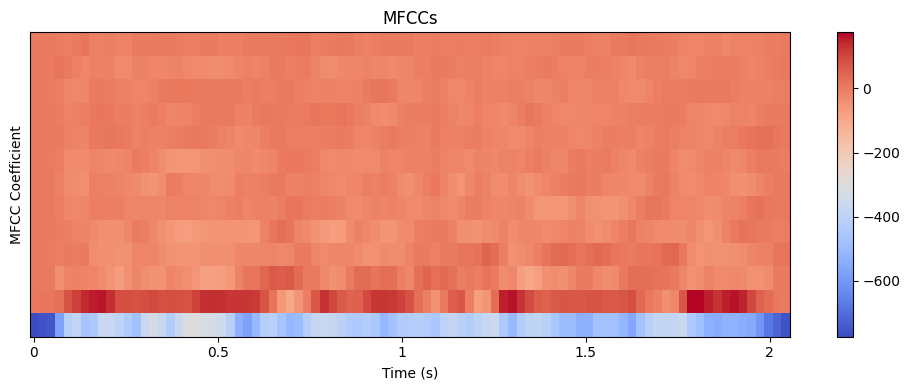

In [ ]:
# Function to load audio and extract MFCCs
def load_timit_audio(path):
    y, sr = librosa.load(path, sr=None)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13).T
    return mfcc

# Analyze the distribution of file lengths
file_lengths = []
for wav_file in timit_wav_files:
    try:
        y, sr = librosa.load(wav_file, sr=None)
        file_lengths.append(len(y) / sr)  # length in seconds
    except Exception as e:
        print(f"Error loading {wav_file}: {e}")

fig1 = go.Figure(data=[go.Histogram(x=file_lengths, nbinsx=50)])
fig1.update_layout(title="Distribution of Audio File Lengths",
                   xaxis_title="Length (seconds)",
                   yaxis_title="Count")
fig1.show()

# Analyze the distribution of MFCC features (example for one file)
example_mfcc = load_timit_audio(timit_wav_files[0])

fig2 = go.Figure(data=[go.Box(y=example_mfcc[:, i], name=f'MFCC {i+1}') for i in range(example_mfcc.shape[1])])
fig2.update_layout(title="Distribution of MFCC Features (Example File)",
                    xaxis_title="MFCC Index",
                    yaxis_title="Feature Value")
fig2.show()

# Visualize an example spectrogram and MFCCs
example_wav_file = timit_wav_files[0]
y, sr = librosa.load(example_wav_file, sr=None)
example_mfcc = load_timit_audio(example_wav_file)

plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
librosa.display.waveshow(y, sr=sr)
plt.title('Waveform')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')

plt.subplot(2, 1, 2)
librosa.display.specshow(librosa.power_to_db(librosa.feature.melspectrogram(y=y, sr=sr), ref=np.max),
                          sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Mel-Spectrogram')
plt.xlabel('Time (s)')
plt.ylabel('Mel frequency')

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
librosa.display.specshow(example_mfcc.T, x_axis='time')
plt.colorbar()
plt.title('MFCCs')
plt.xlabel('Time (s)')
plt.ylabel('MFCC Coefficient')
plt.tight_layout()
plt.show()

# 3.&nbsp;Data Preprocessing

## 3.1.&nbsp;Phoneme Mapping

In [ ]:
# TimitBet 61 phoneme mapping to 39 phonemes
# by Lee, K.-F., & Hon, H.-W. (1989). Speaker-independent phone recognition using hidden Markov models. IEEE Transactions on Acoustics, Speech, and Signal Processing, 37(11), 1641–1648. doi:10.1109/29.46546

phon61_map39 = {
    'iy':'iy',  'ih':'ih',   'eh':'eh',  'ae':'ae',    'ix':'ih',  'ax':'ah',   'ah':'ah',  'uw':'uw',
    'ux':'uw',  'uh':'uh',   'ao':'aa',  'aa':'aa',    'ey':'ey',  'ay':'ay',   'oy':'oy',  'aw':'aw',
    'ow':'ow',  'l':'l',     'el':'l',  'r':'r',      'y':'y',    'w':'w',     'er':'er',  'axr':'er',
    'm':'m',    'em':'m',     'n':'n',    'nx':'n',     'en':'n',  'ng':'ng',   'eng':'ng', 'ch':'ch',
    'jh':'jh',  'dh':'dh',   'b':'b',    'd':'d',      'dx':'dx',  'g':'g',     'p':'p',    't':'t',
    'k':'k',    'z':'z',     'zh':'sh',  'v':'v',      'f':'f',    'th':'th',   's':'s',    'sh':'sh',
    'hh':'hh',  'hv':'hh',   'pcl':'sil', 'tcl':'sil', 'kcl':'sil', 'qcl':'sil','bcl':'sil','dcl':'sil',
    'gcl':'sil','h#':'sil',  '#h':'sil',  'pau':'sil', 'epi': 'sil','nx':'n',   'ax-h':'ah','q':'sil'
}
phon61 = list(phon61_map39.keys())
phon39 = list(set(phon61_map39.values()))

label_p39 = {}
p39_label = {}
for i,p in enumerate(phon39):
    label_p39[p] = i+1
    p39_label[i+1] = p

phon39_map61 = {}
for p61,p39 in phon61_map39.items():
    if not p39 in phon39_map61:
        phon39_map61[p39] = []
    phon39_map61[p39].append(p61)

def get_39_from_61(p):
    return phon61_map39[p]

def remove_stress_marker(phon):
    phon = phon.replace('1','')
    phon = phon.replace('2','')
    return phon

## 3.2.&nbsp;Extract MFCC Features

In [ ]:
def extract_mfcc_features(y, sr=16000, n_mfcc=13, pre_emph=0.97):
    """
    Extracts 39-dim MFCC features (13 static + 13 delta + 13 delta-delta).
    Includes Pre-emphasis and standard ASR windowing (25ms window, 10ms hop).
    """
    # 1. Pre-emphasis (High-pass filter to boost high frequencies)
    y = np.append(y[0], y[1:] - pre_emph * y[:-1])

    # 2. Window Parameters
    # 25ms window = 0.025 * 16000 = 400 samples
    # 10ms hop = 0.010 * 16000 = 160 samples
    n_fft = int(0.025 * sr)
    hop_length = int(0.010 * sr)

    # 3. Extract MFCC
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc, n_fft=n_fft, hop_length=hop_length)

    # 4. Deltas
    delta = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)

    # 5. Stack & Transpose -> (T, 39)
    feats = np.vstack([mfcc, delta, delta2]).T

    # 6. CMVN (Normalization) - CRITICAL for HMMs
    # Subtract mean, divide by variance to center data around 0
    feats = (feats - np.mean(feats, axis=0)) / (np.std(feats, axis=0) + 1e-8)

    return feats, n_fft, hop_length

## 3.3.&nbsp;Prepare Train/Test Dataset

Full Preprocessing Pipeline: Extract features and Gather features into phonemes

In [ ]:
def file_exists_in_repo(repo_id, path, repo_type="dataset"):
    api = HfApi()
    files = api.list_repo_files(repo_id=repo_id, repo_type=repo_type)
    return path in files

def collect_phoneme_sequences(timit_root, subset='train', n_mfcc=13, map_to_39=True, force_reextract=False, repo_id=REPO_ID):
    """
    Walks timit_root (train/test) directories. For each .WAV and .PHN:
      - extracts MFCC frames
      - converts phn sample ranges to frame ranges
      - yields per-phoneme frame sequences (list)
    Returns:
      phoneme_sequences: dict phoneme -> list of np.arrays, each array shape (T_i, D)
    """
    feature_dir = ROOT / 'features'
    feature_dir.mkdir(parents=True, exist_ok=True)
    feat_file = feature_dir / f'{subset}_sequences.pkl'
    remote_path = f'{subset}_sequences.pkl'

    # Check if feature file exists locally or in repo
    if feat_file.exists() and (not force_reextract):
        try:
            print(f'Loading cached features: {feat_file}')
            with open(feat_file, 'rb') as f:
                loader = pickle.load(f)
        except Exception as e:
            print(f"Error loading features: {e}")
        return loader
    elif file_exists_in_repo(repo_id, remote_path, repo_type="dataset"):
        try:
            print(f'Downloading features from repo: {repo_id}/{remote_path}')
            path = hf_hub_download(
                repo_id=repo_id,
                filename=remote_path,
                repo_type="dataset",
                local_dir=feature_dir,
            )
        except Exception as e:
            print(f"Could not download features from repo: {e}")
            print("Proceeding with feature extraction...")
        try:
            with open(feat_file, 'rb') as f:
                loader = pickle.load(f)
        except Exception as e:
            print(f"Error loading features: {e}")
        return loader

    phoneme_sequences = defaultdict(list)
    subset_dir = os.path.join(timit_root, subset.upper())  # TRAIN or TEST
    wav_files = glob.glob(os.path.join(subset_dir, "**/*.WAV"), recursive=True)
    if not wav_files:
        wav_files = glob.glob(os.path.join(subset_dir, "**/*.wav"), recursive=True)

    print(f"Scanning {len(wav_files)} audio files...")

    for wav_path in wav_files:
        phn_path = os.path.splitext(wav_path)[0] + ".PHN"
        if not os.path.exists(phn_path):
            phn_path = os.path.splitext(wav_path)[0] + ".phn"
            if not os.path.exists(phn_path): continue

        try:
            # 1. Load FULL Audio
            y, sr = librosa.load(wav_path, sr=None)

            # 2. Extract FULL Features
            feats, _, hop_length = extract_mfcc_features(y, sr=sr, n_mfcc=n_mfcc)
            total_frames = feats.shape[0]

            # 3. Parse PHN file & Get Ranges
            with open(phn_path, 'r') as f:
                for line in f:
                    start_frame, end_frame, label = line.strip().split()
                    start_frame, end_frame = int(start_frame), int(end_frame)
                    label = remove_stress_marker(label)
                    if map_to_39:
                        label = get_39_from_61(label)

                    start_frame = int(np.floor(start_frame / hop_length))
                    end_frame = int(np.ceil(end_frame / hop_length))  # exclusive end

                    # Boundary checks
                    start_frame = max(0, start_frame)
                    end_frame = min(total_frames, end_frame)

                    if end_frame < start_frame : continue # Skip invalid

                    # SLICE THE FEATURES (Preserving context!)
                    seg_feats = feats[start_frame:end_frame, :]
                    phoneme_sequences[label].append(seg_feats)

        except Exception as e:
            print(f"Error processing {wav_path}: {e}")
            continue

    phoneme_sequences = {k: v for k, v in phoneme_sequences.items() if len(v) > 0} # Remove empty classes
    try:
        with open(feat_file, 'wb') as f:
            pickle.dump(phoneme_sequences, f)
        print(f"Train features saved successfully to {feat_file}")
    except Exception as e:
        print(f"Error saving features: {e}")
    return phoneme_sequences

Plotting distribution of phonemes using Plotly

In [ ]:
def plot_phoneme_distribution(phoneme_sequences, subset='Train'):
    phoneme_counts = {phn: len(seqs) for phn, seqs in phoneme_sequences.items()}
    phoneme_df = pd.DataFrame(list(phoneme_counts.items()), columns=['Phoneme', 'Count'])
    phoneme_df = phoneme_df.sort_values(by='Count', ascending=False)

    fig_phoneme_dist = px.bar(phoneme_df, x='Phoneme', y='Count',
                              title=f'Distribution of Phonemes in {subset} Dataset',
                              labels={'Phoneme': 'Phoneme', 'Count': 'Number of Sequences'})
    fig_phoneme_dist.update_layout(xaxis_tickangle=-45)
    fig_phoneme_dist.show()

Collect for Train/Test Dataset

In [ ]:
train_sequences = collect_phoneme_sequences(data_path, subset='train', n_mfcc=13)
print("Number of phonemes found in train set:", len(train_sequences))
test_sequences = collect_phoneme_sequences(data_path, subset='test', n_mfcc=13)
print(f"Number of phonemes found in test set: {len(test_sequences)}")

train_sequences.pkl:   0%|          | 0.00/253M [00:00<?, ?B/s]

Number of phonemes found in train set: 39


test_sequences.pkl:   0%|          | 0.00/92.4M [00:00<?, ?B/s]

Number of phonemes found in test set: 39


Phoneme Distribution for Train/Test Dataset

In [ ]:
plot_phoneme_distribution(train_sequences, 'Train')
plot_phoneme_distribution(test_sequences, 'Test')

# 4.&nbsp;Model Implementation

## 4.1.&nbsp;Discrete HMM implementation (using log space for speech)

In [ ]:
class MyDiscreteHMM:
    def __init__(self, n_states, n_symbols, left_to_right=False, rng_seed=None):
        self.n_states = int(n_states)
        self.n_symbols = int(n_symbols)
        self.left_to_right = bool(left_to_right)
        self.rng = np.random.RandomState(rng_seed)
        self.history = []
        # tiny values for numeric safety
        self._tiny = 1e-300
        self._count_eps = 1e-12

        # initialize uniformly in prob-space, convert to log
        A = np.full((self.n_states, self.n_states), 1.0 / self.n_states)
        B = np.full((self.n_states, self.n_symbols), 1.0 / self.n_symbols)
        pi = np.full(self.n_states, 1.0 / self.n_states)

        self.log_A = np.log(A + self._tiny)
        self.log_B = np.log(B + self._tiny)
        self.log_pi = np.log(pi + self._tiny)

        if self.left_to_right:
            self._enforce_lr_mask_and_normalize_A()

    # ---------- helpers ----------
    def _normalize_log_rows(self, log_mat):
        """Normalize rows of a log matrix so exp(rows) sum to 1; returns log(normalized)."""
        row_logsum = logsumexp(log_mat, axis=1, keepdims=True)
        return log_mat - row_logsum

    def _enforce_lr_mask_and_normalize_A(self):
        """If left_to_right, force only self-loop and next-state transitions and renormalize rows."""
        mask = np.full_like(self.log_A, -np.inf)
        for i in range(self.n_states):
            mask[i, i] = 0.0
            if i + 1 < self.n_states:
                mask[i, i+1] = 0.0
        # apply mask: keep old values where allowed, -inf elsewhere
        self.log_A = np.where(np.isneginf(mask), -np.inf, self.log_A)
        # normalize rows
        self.log_A = self._normalize_log_rows(self.log_A)

    # ---------- initialization ----------
    def init_params(self, sequences, noise_logB=1e-2):
        """
        Initialize parameters using data-driven small perturbations:
        - add tiny noise to log_B per-state to break symmetry
        - initialize A and pi with slight randomness
        sequences: list of sequences (each a list/array of ints 0..n_symbols-1)
        """
        # randomize pi slightly (but keep valid prob)
        pi = np.abs(self.rng.randn(self.n_states)) + 1e-2
        pi = pi / pi.sum()
        self.log_pi = np.log(pi + self._tiny)

        # initialize A with small preference for self-loop (if not left_to_right)
        A = np.abs(self.rng.randn(self.n_states, self.n_states)) + 0.01
        # optionally encourage self-loop
        for i in range(self.n_states):
            A[i, i] += 1.0
        A = A / A.sum(axis=1, keepdims=True)
        self.log_A = np.log(A + self._tiny)
        if self.left_to_right:
            self._enforce_lr_mask_and_normalize_A()

        # initialize B from empirical frequencies if possible
        all_obs = np.concatenate([np.asarray(s, dtype=int).ravel() for s in sequences if len(s) > 0]) \
                  if any(len(s) > 0 for s in sequences) else None
        if all_obs is not None and all_obs.size > 0:
            # empirical distribution of symbols
            counts = np.bincount(all_obs, minlength=self.n_symbols).astype(float) + 1e-6
            base = counts / counts.sum()
            # for each state, slightly perturb base distribution
            B = np.tile(base[None, :], (self.n_states, 1))
            B += noise_logB * np.abs(self.rng.randn(self.n_states, self.n_symbols))
            B = B / B.sum(axis=1, keepdims=True)
            self.log_B = np.log(B + self._tiny)
        else:
            # random small perturbation around uniform
            B = np.full((self.n_states, self.n_symbols), 1.0 / self.n_symbols)
            B += noise_logB * np.abs(self.rng.randn(self.n_states, self.n_symbols))
            B = B / B.sum(axis=1, keepdims=True)
            self.log_B = np.log(B + self._tiny)

    # ---------- Forward / Backward ----------
    def forward(self, obs_seq):
        """
        Forward algorithm in log-space.
        obs_seq: iterable/1D-array of ints (0..n_symbols-1)
        Returns: (log_prob, log_alpha)
        """
        obs = np.asarray(obs_seq, dtype=int)
        T = len(obs)
        if T == 0:
            return -np.inf, np.zeros((0, self.n_states))

        log_alpha = np.full((T, self.n_states), -np.inf)
        # t=0
        log_alpha[0] = self.log_pi + self.log_B[:, obs[0]]
        for t in range(1, T):
            # log_alpha[t-1][:, None] shape (N,1), self.log_A (N,N) -> broadcast to (N,N)
            mat = log_alpha[t-1][:, None] + self.log_A  # (N_prev, N_next)
            log_alpha[t] = logsumexp(mat, axis=0) + self.log_B[:, obs[t]]
        log_prob = logsumexp(log_alpha[-1])
        return log_prob, log_alpha

    def backward(self, obs_seq):
        """
        Backward algorithm in log-space.
        Returns log_beta shaped (T, N)
        """
        obs = np.asarray(obs_seq, dtype=int)
        T = len(obs)
        if T == 0:
            return np.zeros((0, self.n_states))
        log_beta = np.full((T, self.n_states), -np.inf)
        log_beta[T-1] = 0.0
        for t in range(T-2, -1, -1):
            # We need: for each i: logsum_j [ A[i,j] + B[j, obs[t+1]] + beta[t+1, j] ]
            # So add B[:, obs] and beta[t+1] as row-vectors to broadcast across columns of A
            term = self.log_A + (self.log_B[:, obs[t+1]][None, :]) + (log_beta[t+1][None, :])
            log_beta[t] = logsumexp(term, axis=1)
        return log_beta

    # ---------- Baum-Welch EM ----------
    def baum_welch(self, sequences, n_iter=10, verbose=False):
        """
        sequences: list of integer sequences (each element 0..n_symbols-1)
        n_iter: number of EM iterations
        """
        self.history = []
        for it in range(n_iter):
            # accumulators in probability domain
            xi_sum = np.zeros((self.n_states, self.n_states))   # sum_t xi_t(i,j)
            gamma_sum = np.zeros(self.n_states)                 # sum_t gamma_t(i) across all sequences
            gamma_obs_counts = np.zeros(self.n_states)          # denom for B (same as gamma_sum)
            B_numer = np.zeros((self.n_states, self.n_symbols)) # numerator counts for B
            pi_accum = np.zeros(self.n_states)                  # start counts
            total_loglik = 0.0

            for obs_seq in sequences:
                obs = np.asarray(obs_seq, dtype=int)
                T = len(obs)
                if T == 0:
                    continue
                # E-step
                log_P, log_alpha = self.forward(obs)
                log_beta = self.backward(obs)
                total_loglik += log_P

                log_gamma = log_alpha + log_beta - log_P    # (T, N)
                gamma = np.exp(log_gamma)                   # back to probability domain (T,N)

                # accumulate pi from first frame
                pi_accum += gamma[0]
                # accumulate gamma counts for B and for denom_A
                gamma_sum += np.sum(gamma, axis=0)         # (N,)
                gamma_obs_counts += np.sum(gamma, axis=0)  # same as above (kept semantically)

                # update B numerator: sum_t gamma_t(i) * one_hot(obs_t)
                # vectorized: for each t, add gamma[t][:,None] * one_hot
                # efficient matrix multiply: gamma.T @ one_hot(obs)
                one_hot = np.zeros((T, self.n_symbols))
                one_hot[np.arange(T), obs] = 1.0
                B_numer += gamma.T @ one_hot               # (N, S)

                # accumulate xi
                if T > 1:
                    log_alpha_expanded = log_alpha[:-1][:, :, None]                # (T-1, N, 1)
                    log_beta_expanded  = log_beta[1:][:, None, :]                  # (T-1, 1, N)
                    log_A_expanded     = self.log_A[None, :, :]                    # (1, N, N)
                    log_B_next         = self.log_B[:, obs[1:]]                    # (N, T-1)
                    log_B_expanded     = log_B_next.T[:, None, :]                  # (T-1, 1, N)

                    # log_xi: (T-1, N, N)
                    log_xi = (
                        log_alpha_expanded +
                        log_A_expanded +
                        log_B_expanded +
                        log_beta_expanded -
                        log_P
                    )

                    # Sum over time
                    xi_sum += np.exp(log_xi).sum(axis=0)

            # record log-likelihood
            self.history.append(total_loglik)
            if verbose:
                print(f"EM iter {it} LL={total_loglik:.6f}")

            # ---------- M-step ----------
            # Update pi: normalized average of start probabilities
            if pi_accum.sum() <= 0:
                # keep previous pi if no data
                pass
            else:
                pi_new = pi_accum / (pi_accum.sum() + self._count_eps)
                self.log_pi = np.log(np.maximum(pi_new, self._tiny))

            # Update A: xi_sum[i,j] / sum_j xi_sum[i,j]
            row_sums = xi_sum.sum(axis=1)  # (N,)
            A_new = np.zeros_like(xi_sum)
            # Only update rows that have nonzero counts
            mask_nonzero = row_sums > 0
            if np.any(mask_nonzero):
                A_new[mask_nonzero] = xi_sum[mask_nonzero] / (row_sums[mask_nonzero][:, None] + self._count_eps)
                # ensure numeric safety and normalize rows
                A_new[mask_nonzero] = A_new[mask_nonzero] / (A_new[mask_nonzero].sum(axis=1, keepdims=True) + self._count_eps)
                self.log_A = np.log(np.maximum(A_new, self._tiny))
            # if left_to_right -> enforce mask and renormalize
            if self.left_to_right:
                self._enforce_lr_mask_and_normalize_A()
            else:
                # ensure log_A rows are normalized (in case some rows had 0 xi_sum)
                self.log_A = self._normalize_log_rows(self.log_A)

            # Update B: for each state, symbol probabilities
            denom_B = gamma_obs_counts + self._count_eps
            B_new = B_numer / denom_B[:, None]
            # normalize in case of numerical drift
            B_new = B_new / (B_new.sum(axis=1, keepdims=True) + self._count_eps)
            self.log_B = np.log(np.maximum(B_new, self._tiny))

    # ---------- Viterbi (best path) ----------
    def viterbi(self, obs_seq):
        """
        Viterbi best path decoding (returns best_state_path, log_prob)
        """
        obs = np.asarray(obs_seq, dtype=int)
        T = len(obs)
        if T == 0:
            return np.zeros(0, dtype=int), -np.inf

        delta = np.full((T, self.n_states), -np.inf)
        psi = np.zeros((T, self.n_states), dtype=int)

        delta[0] = self.log_pi + self.log_B[:, obs[0]]
        for t in range(1, T):
            # compute scores for each (prev_state -> next_state)
            scores = delta[t-1][:, None] + self.log_A  # (N_prev, N_next)
            psi[t] = np.argmax(scores, axis=0)
            delta[t] = np.max(scores, axis=0) + self.log_B[:, obs[t]]

        best_last = np.argmax(delta[-1])
        best_logp = np.max(delta[-1])

        path = np.zeros(T, dtype=int)
        path[-1] = best_last
        for t in range(T-2, -1, -1):
            path[t] = psi[t+1, path[t+1]]
        return path, best_logp

## 4.2.&nbsp;Base HMM implementation (for GaussianHMM and GMM-HMM)

In [ ]:
class BaseHMM:
    def __init__(self, n_states, left_to_right=True):
        self.n_states = n_states
        self.left_to_right = left_to_right
        self.history = []
        # log transition matrix initialised below
        self.log_A = np.full((n_states, n_states), -np.inf)
        if left_to_right:
            for i in range(n_states):
                if i == n_states - 1:
                    self.log_A[i, i] = 0.0
                else:
                    # prefer self-loop, small prob to move forward
                    self.log_A[i, i] = np.log(0.6)
                    self.log_A[i, i+1] = np.log(0.4)
        else:
            self.log_A = np.log(np.full((n_states, n_states), 1.0 / n_states))

        self.log_pi = np.full(n_states, -np.inf)
        self.log_pi[0] = 0.0  # start in state 0 by default

    def _enforce_lr_mask_and_normalize_A(self, tiny=1e-20):
        """Ensure self.log_A respects left-to-right topology if requested, and rows sum to 1 (in log)."""
        if self.left_to_right:
            mask = np.full_like(self.log_A, -np.inf)
            for i in range(self.n_states):
                mask[i, i] = 0.0
                if i + 1 < self.n_states:
                    mask[i, i+1] = 0.0
            # mask: allowed positions have 0, disallowed -inf
            self.log_A = np.where(np.isneginf(mask), -np.inf, self.log_A)
        # normalize rows in log space
        row_log_sums = logsumexp(self.log_A, axis=1, keepdims=True)
        # Avoid -inf / NaNs: if a row is all -inf (shouldn't happen), leave it as is
        valid = ~np.isneginf(row_log_sums).ravel()
        if np.any(valid):
            self.log_A[valid] = self.log_A[valid] - row_log_sums[valid]

    def forward(self, obs_seq):
        T = obs_seq.shape[0]
        log_B = self.compute_log_B(obs_seq)  # (T, n_states)
        log_alpha = np.full((T, self.n_states), -np.inf)
        log_alpha[0] = self.log_pi + log_B[0]
        for t in range(1, T):
            # shape (n_states, n_states): prev_state x next_state
            mat = log_alpha[t-1][:, None] + self.log_A
            log_alpha[t] = logsumexp(mat, axis=0) + log_B[t]
        log_prob = logsumexp(log_alpha[-1])
        return log_prob, log_alpha, log_B

    def backward(self, obs_seq, log_B):
        T = obs_seq.shape[0]
        log_beta = np.full((T, self.n_states), -np.inf)
        log_beta[T-1] = 0.0
        for t in range(T-2, -1, -1):
            # self.log_A (i->j), log_B[t+1] (j), log_beta[t+1] (j)
            mat = self.log_A + log_B[t+1] + log_beta[t+1]  # shape (i,j)
            log_beta[t] = logsumexp(mat, axis=1)
        return log_beta

    # compute_log_B must be implemented by subclass
    def compute_log_B(self, obs_seq):
        raise NotImplementedError

## 4.3.&nbsp;Gaussian HMM implementation (using log space for speech)

In [ ]:
class MyGaussianHMM(BaseHMM):
    def __init__(self, n_states, obs_dim, left_to_right=True, var_floor=1e-6):
        super().__init__(n_states, left_to_right)
        self.obs_dim = obs_dim
        self.var_floor = var_floor
        # Gaussian parameters per state (diagonal covariances)
        self.means = np.zeros((n_states, obs_dim))
        self.vars = np.ones((n_states, obs_dim))  # diag variances

    def init_params(self, sequences, seed=42):
        """Time-sorted KMeans initialization with robust fallbacks."""
        pooled_frames = []
        pooled_times = []
        for seq in sequences:
            T = len(seq)
            if T == 0: continue
            pooled_frames.append(seq)
            pooled_times.append(np.linspace(0, 1, T))

        if not pooled_frames:
            # fallback random initialization
            self.means = np.random.randn(self.n_states, self.obs_dim)
            self.vars = np.ones((self.n_states, self.obs_dim)) * 1.0
            return

        X = np.vstack(pooled_frames)
        times = np.concatenate(pooled_times)

        # KMeans clustering to get centers, then sort by average time of cluster
        try:
            kmeans = MiniBatchKMeans(n_clusters=self.n_states, random_state=seed,
                                     batch_size=256, n_init='auto')
            labels = kmeans.fit_predict(X)
            centers = kmeans.cluster_centers_
        except Exception:
            # fallback: evenly spaced centers from data quantiles
            idx = np.linspace(0, X.shape[0]-1, self.n_states).astype(int)
            centers = X[idx]
            labels = np.zeros(X.shape[0], dtype=int)
            # nearest center assignment
            from sklearn.metrics import pairwise_distances_argmin_min
            labels, _ = pairwise_distances_argmin_min(X, centers)

        # compute average times per cluster and sort states by temporal order
        avg_times = []
        for k in range(self.n_states):
            mask = (labels == k)
            if np.any(mask):
                avg_times.append(np.mean(times[mask]))
            else:
                avg_times.append(999.0)
        sorted_indices = np.argsort(avg_times)
        # set means in that temporal order
        self.means = centers[sorted_indices]

        # remap labels (old cluster id -> new state id)
        map_old_to_new = {old: new for new, old in enumerate(sorted_indices)}
        new_labels = np.array([map_old_to_new[l] for l in labels])

        # compute per-state variances; fallback to global variance if empty
        global_var = np.var(X, axis=0) + self.var_floor
        for s in range(self.n_states):
            mask = (new_labels == s)
            if np.any(mask):
                self.vars[s] = np.var(X[mask], axis=0) + self.var_floor
            else:
                self.vars[s] = global_var.copy()

        # ensure floors
        self.vars = np.maximum(self.vars, self.var_floor)

    def compute_log_B(self, obs_seq):
        """
        Diagonal Gaussian log-pdf:
        log p(x) = -0.5 * (sum_d log(2*pi*var_d) + sum_d (x_d - mu_d)^2 / var_d)
        Return shape (T, n_states)
        """
        T = obs_seq.shape[0]
        log_B = np.zeros((T, self.n_states))
        vars_safe = np.maximum(self.vars, self.var_floor)  # (S, D)
        # precompute per-state log determinant term: sum_d log(2*pi*var_d)
        log_det_term = np.sum(np.log(2.0 * np.pi * vars_safe), axis=1)  # (S,)
        const = -0.5 * log_det_term  # (S,)
        for j in range(self.n_states):
            diff = obs_seq - self.means[j]  # (T, D)
            quad = np.sum((diff**2) / vars_safe[j], axis=1)  # (T,)
            log_B[:, j] = const[j] - 0.5 * quad
        return log_B

    def baum_welch(self, sequences, n_iter=10):
        self.history = []
        for it in range(n_iter):
            # accumulators
            gamma_sum = np.zeros(self.n_states)               # sum_t gamma_t(s)
            weighted_sum = np.zeros((self.n_states, self.obs_dim))   # sum_t gamma_t(s) * x_t
            weighted_outer = np.zeros((self.n_states, self.obs_dim)) # sum_t gamma_t(s) * x_t^2 (diag)
            xi_sum = np.zeros((self.n_states, self.n_states))
            pi_accum = np.full(self.n_states, 1e-12)
            total_ll = 0.0

            for obs in sequences:
                T = len(obs)
                if T == 0: continue
                log_P, log_alpha, log_B = self.forward(obs)
                log_beta = self.backward(obs, log_B)
                total_ll += log_P

                # gamma_t(s) in log domain -> convert to prob
                log_gamma = log_alpha + log_beta - log_P  # (T, S)
                gamma = np.exp(log_gamma)

                # accumulate start counts for pi
                pi_accum += np.exp(log_gamma[0])

                gamma_sum += np.sum(gamma, axis=0)  # (S,)
                weighted_sum += gamma.T @ obs        # (S, D)
                weighted_outer += gamma.T @ (obs**2) # (S, D)

                # transitions xi
                if T > 1:
                    # vectorized across time: compute mat for all t, accumulate xi_sum
                    for t in range(T - 1):
                        mat = log_alpha[t][:, None] + self.log_A + log_B[t+1] + log_beta[t+1]
                        log_xi = mat - log_P
                        xi = np.exp(log_xi)
                        xi_sum += xi

            self.history.append(total_ll)

            # M-step for Gaussian parameters
            prev_means = self.means.copy()
            prev_vars = self.vars.copy()

            # small count floor
            count_floor = 1e-12
            for s in range(self.n_states):
                denom = gamma_sum[s]
                if denom < 1e-8:
                    # state not visited — keep previous params (small jitter optional)
                    # jitter: uncomment next two lines if you prefer small random jitter
                    # self.means[s] = prev_means[s] + 1e-6 * np.random.randn(self.obs_dim)
                    # self.vars[s]  = np.maximum(prev_vars[s], self.var_floor)
                    continue

                # update mean
                self.means[s] = weighted_sum[s] / (denom + count_floor)
                # update diagonal variance: E[x^2] - (E[x])^2
                ex2 = weighted_outer[s] / (denom + count_floor)
                self.vars[s] = ex2 - (self.means[s] ** 2)
                # floor variances
                self.vars[s] = np.maximum(self.vars[s], self.var_floor)

            # update transitions
            row_sums = xi_sum.sum(axis=1) + 1e-12
            for i in range(self.n_states):
                if row_sums[i] > 0:
                    new_row = xi_sum[i] / row_sums[i]
                    new_row = np.maximum(new_row, 1e-300)
                    self.log_A[i] = np.log(new_row)
                else:
                    # leave previous row if no evidence
                    pass

            # enforce left-to-right topology and renormalize rows (if requested)
            self._enforce_lr_mask_and_normalize_A()

            # update initial probabilities pi from accumulated start counts
            pi_norm = pi_accum / np.sum(pi_accum)
            self.log_pi = np.log(np.maximum(pi_norm, 1e-300))

            # end iteration

## 4.4.&nbsp;GMM-HMM implementation (using log space for speech)

In [ ]:
class MyGMMHMM(BaseHMM):
    def __init__(self, n_states, n_mix, obs_dim, left_to_right=True, var_floor=1e-6):
        super().__init__(n_states, left_to_right)
        self.n_mix = n_mix
        self.obs_dim = obs_dim
        self.var_floor = var_floor
        # GMM params per state
        self.weights = np.full((n_states, n_mix), 1.0 / n_mix)
        self.means = np.zeros((n_states, n_mix, obs_dim))
        self.vars = np.ones((n_states, n_mix, obs_dim))  # diag covariances

    def init_params(self, sequences, seed=42):
        """
        Initialize GMM params per state using uniform segmentation per sequence.
        sequences: list of (T_i, obs_dim) arrays
        """
        # collect per-state pools by uniform segmentation
        pools = [ [] for _ in range(self.n_states) ]
        for seq in sequences:
            T = len(seq)
            if T == 0: continue
            # assign each frame to a state by relative time
            # segment index = floor(t/T * n_states), clipped
            idxs = np.minimum((np.floor(np.arange(T) / float(T) * self.n_states)).astype(int), self.n_states-1)
            for t in range(T):
                pools[idxs[t]].append(seq[t])

        # fallback: if any pool is empty, do a global kmeans over frames and map clusters to time order
        all_frames = np.vstack([s for s in sequences if len(s) > 0]) if any(len(s)>0 for s in sequences) else None
        if all_frames is None:
            # nothing to init from
            return

        for s in range(self.n_states):
            if len(pools[s]) < max(10, self.n_mix):
                # not enough frames locally -> fallback to clustering on ALL frames into n_mix components
                # but we still try to create sensible means/vars by clustering the whole set into n_states first
                # Use MiniBatchKMeans to get centroid assignment then select frames nearest to centroid s (if possible)
                # Fallback simpler: sample random frames
                pools[s] = all_frames[np.random.choice(all_frames.shape[0], size=min(200, all_frames.shape[0]), replace=False)].tolist()

        # Fit GaussianMixture per-state
        for s in range(self.n_states):
            Xs = np.vstack(pools[s])
            # if too few samples relative to n_mix, reduce components temporarily
            n_comp = min(self.n_mix, max(1, len(Xs)//5))
            try:
                gmm = GaussianMixture(n_components=n_comp, covariance_type='diag', random_state=seed)
                gmm.fit(Xs)
                # if we reduced n_components, pad with small noise
                weights = np.full(self.n_mix, 1.0/self.n_mix)
                means = np.tile(np.mean(Xs, axis=0), (self.n_mix,1))
                covs = np.tile(np.var(Xs, axis=0)+self.var_floor, (self.n_mix,1))
                weights[:n_comp] = gmm.weights_
                means[:n_comp,:] = gmm.means_
                covs[:n_comp,:] = gmm.covariances_
                # normalize weights
                weights = weights / np.sum(weights)
                self.weights[s] = weights
                self.means[s] = means
                self.vars[s] = np.maximum(covs, self.var_floor)
            except Exception as e:
                # worst-case fallback: random jitter around global mean
                gm = np.mean(all_frames, axis=0)
                self.means[s] = gm + 0.01 * np.random.randn(self.n_mix, self.obs_dim)
                self.vars[s] = np.maximum(np.var(all_frames, axis=0) + 1e-3, self.var_floor)
                self.weights[s] = np.full(self.n_mix, 1.0/self.n_mix)

    def _log_diag_gaussian(self, X, means, vars_):
        """
        Compute log N(x | mean, diag(vars_)) for many x.
        X: (T, D)
        means: (K, D)
        vars_: (K, D)
        Returns: (T, K) array of log pdfs
        """
        # compute per-component constant: -0.5 * sum_d log(2*pi*var_d)
        # and quadratic term: -0.5 * sum_d (x_d - mu_d)^2 / var_d
        # We vectorize:
        K = means.shape[0]
        T = X.shape[0]
        # shape (K, D)
        log_det = -0.5 * np.sum(np.log(2.0 * np.pi * vars_), axis=1)  # (K,)
        # compute (T, K) quadratic terms efficiently
        # Use broadcasting: X[:, None, :] - means[None, :, :] -> (T, K, D)
        diff = X[:, None, :] - means[None, :, :]  # (T, K, D)
        quad = -0.5 * np.sum((diff**2) / vars_[None, :, :], axis=2)  # (T, K)
        return quad + log_det[None, :]

    def compute_log_B(self, obs_seq):
        """
        Compute log B_t(s) = log p(x_t | state s) = log sum_k w_{s,k} * N(x_t | mu_{s,k}, var_{s,k})
        Returns (T, n_states)
        """
        T = obs_seq.shape[0]
        log_B = np.zeros((T, self.n_states))
        for s in range(self.n_states):
            # means: (K, D), vars: (K, D)
            vars_safe = np.maximum(self.vars[s], self.var_floor)
            log_gauss = self._log_diag_gaussian(obs_seq, self.means[s], vars_safe)  # (T, K)
            # add log weights
            log_weighted = log_gauss + np.log(self.weights[s] + 1e-300)[None, :]
            # log-sum over mixtures
            log_B[:, s] = logsumexp(log_weighted, axis=1)
        return log_B

    def baum_welch(self, sequences, n_iter=10):
        """
        Baum-Welch EM training over sequences (list of arrays).
        """
        self.history = []
        for it in range(n_iter):
            # accumulators
            gamma_sum = np.zeros((self.n_states, self.n_mix))         # sum_t gamma_{t,s,k}
            weighted_sum = np.zeros((self.n_states, self.n_mix, self.obs_dim))  # sum_t gamma * x_t
            weighted_outer = np.zeros((self.n_states, self.n_mix, self.obs_dim)) # sum_t gamma * x_t^2 (diag)
            xi_sum = np.zeros((self.n_states, self.n_states))
            pi_accum = np.full(self.n_states, 1e-12)
            total_ll = 0.0

            for obs in sequences:
                T = len(obs)
                if T == 0: continue
                log_P, log_alpha, log_B = self.forward(obs)
                log_beta = self.backward(obs, log_B)
                total_ll += log_P

                # gamma_state: (T, S) in prob domain
                log_gamma_state = log_alpha + log_beta - log_P
                gamma_state = np.exp(log_gamma_state)  # (T, S)

                # update pi accumulator
                pi_accum += np.exp(log_gamma_state[0])

                # per-state GMM responsibilities and accumulators
                for s in range(self.n_states):
                    # per-component log gaussian: (T, K)
                    vars_safe = np.maximum(self.vars[s], self.var_floor)
                    log_gauss = self._log_diag_gaussian(obs, self.means[s], vars_safe)  # (T, K)
                    comp_log = log_gauss + np.log(self.weights[s] + 1e-300)[None, :]     # (T, K)
                    # responsibilities p(k | x_t, s) in stable way
                    log_den = logsumexp(comp_log, axis=1, keepdims=True)  # (T,1)
                    resp = np.exp(comp_log - log_den)  # (T, K)

                    # gamma_sk = gamma_state[:, s:s+1] * resp  => (T, K)
                    gamma_sk = gamma_state[:, s:s+1] * resp

                    gamma_sum[s] += np.sum(gamma_sk, axis=0)            # (K,)
                    weighted_sum[s] += gamma_sk.T @ obs                 # (K, D)
                    weighted_outer[s] += gamma_sk.T @ (obs**2)          # (K, D)  (using diag sum)

                # xi (transition) updates: only valid transitions contribute (log_A might be -inf)
                if T > 1:
                    for t in range(T - 1):
                        # mat shape (i,j)
                        mat = log_alpha[t][:, None] + self.log_A + log_B[t+1] + log_beta[t+1]
                        # normalize to get xi_t as probabilities
                        log_xi = mat - log_P
                        xi = np.exp(log_xi)
                        xi_sum += xi

            # record LL
            self.history.append(total_ll)

            # M-step: update GMM params per state
            for s in range(self.n_states):
                denom = gamma_sum[s] + 1e-12  # (K,)
                # weights
                w = denom / np.sum(denom)
                self.weights[s] = np.maximum(w, 1e-12)
                self.weights[s] /= np.sum(self.weights[s])

                # means
                self.means[s] = weighted_sum[s] / denom[:, None]

                # variances (diagonal) via E[x^2] - (E[x])^2
                ex2 = weighted_outer[s] / denom[:, None]
                self.vars[s] = ex2 - (self.means[s] ** 2)
                # numerical fixes
                # If any var dimension is negative due to numeric error, floor it
                self.vars[s] = np.maximum(self.vars[s], self.var_floor)

            # update transitions A (normalize rows)
            row_sums = xi_sum.sum(axis=1) + 1e-12
            for i in range(self.n_states):
                if row_sums[i] > 0:
                    new_row = xi_sum[i] / row_sums[i]
                    # avoid zeros -> floor, then log
                    new_row = np.maximum(new_row, 1e-300)
                    self.log_A[i] = np.log(new_row)
                else:
                    # no transitions observed from state i in this batch - keep previous (or leave as is)
                    pass

            # enforce left-to-right mask if required + normalize A
            self._enforce_lr_mask_and_normalize_A()

            # update log_pi from accumulated pi counts
            pi_norm = pi_accum / np.sum(pi_accum)
            self.log_pi = np.log(np.maximum(pi_norm, 1e-300))

# 5.&nbsp;Training and Evaluation

## 5.1.&nbsp;Model Training and Validation

Helper for DiscreteHMM

In [ ]:
def train_codebook(data_dict, n_clusters=64, max_per_phoneme=5000):
    """
    Balanced K-Means training for TIMIT:
    - limits samples per phoneme to avoid vowel dominance
    - prevents empty clusters
    """
    print(f"Training balanced codebook (K={n_clusters})...")
    frames_list = []
    for phn, seqs in data_dict.items():
        phn_frames = np.vstack(seqs)
        # subsample to balance phonemes
        if len(phn_frames) > max_per_phoneme:
            idx = np.random.choice(len(phn_frames), max_per_phoneme, replace=False)
            phn_frames = phn_frames[idx]
        frames_list.append(phn_frames)
    all_frames = np.vstack(frames_list)
    kmeans = MiniBatchKMeans(
        n_clusters=n_clusters,
        batch_size=2048,
        random_state=RND,
        n_init='auto',
        init='k-means++'
    )
    kmeans.fit(all_frames)
    return kmeans

def quantize_sequences(data_dict, kmeans):
    quantized = {}
    for phn, seqs in data_dict.items():
        stacked = np.vstack(seqs)
        q_all = kmeans.predict(stacked)
        # split back into original lengths
        sizes = [len(s) for s in seqs]
        splits = np.cumsum(sizes[:-1])
        quantized[phn] = np.split(q_all, splits)
    return quantized

Training driver

In [ ]:
def train_phoneme_hmms(train_sequences, model_type, config, obs_dim=39, force_retrain=False, repo_id=REPO_ID):
    """
    Train one HMM per phoneme.
    Returns dict phoneme -> trained HMMs, dict phoneme -> history
    """
    n_iter = config['n_iter']

    model_dir = ROOT / 'models'
    model_dir.mkdir(parents=True, exist_ok=True)
    model_file = model_dir / f'{model_type}_niter{n_iter}.pkl'
    remote_path = f'{model_type}_niter{n_iter}.pkl'

    # 1. Try loading from local cache
    if model_file.exists() and (not force_retrain):
        try:
            with open(model_file, 'rb') as f:
                loaded_models = pickle.load(f)
                loaded_histories = {phn: model.history for phn, model in loaded_models.items()}
                print("Loaded models and histories from local. Continue with evaluation.")
                return loaded_models, loaded_histories
        except Exception as e:
            print(f"Error loading from local cache: {e}. Checking remote or retraining.")
    # 2. If not loaded locally, try downloading from Hugging Face and then loading
    elif file_exists_in_repo(repo_id, remote_path, repo_type="dataset") and (not force_retrain):
        try:
            print(f'Downloading models from repo: {repo_id}/{remote_path}')
            path = hf_hub_download(
                repo_id=repo_id,
                filename=remote_path,
                repo_type="dataset",
                local_dir=model_dir,
            )
            if model_file.exists():
                with open(model_file, 'rb') as f:
                    loaded_models = pickle.load(f)
                    loaded_histories = {phn: model.history for phn, model in loaded_models.items()}
                    print("Downloaded and loaded models from Hugging Face and extracted histories. Continue with evaluation.")
                    return loaded_models, loaded_histories
            else:
                print(f"Downloaded file not found at {model_file}. Retraining.")
        except Exception as e:
            print(f"Could not download or load models from Hugging Face: {e}. Proceeding with model training.")

    models = {}
    histories = {}
    for phn, sequences in tqdm(train_sequences.items(), desc="Training phoneme HMMs"):
        if len(sequences) < 3: continue
        n_states = config['n_states']
        if phn.lower() == 'sil': n_states = 5

        if model_type == "MyGaussianHMM":
            model = MyGaussianHMM(n_states, obs_dim, left_to_right=True)
            model.init_params(sequences, seed=RND)
        elif model_type == "MyGMMHMM":
            model = MyGMMHMM(n_states, config['n_mix'], obs_dim, left_to_right=True)
            model.init_params(sequences, seed=RND)
        elif model_type == "MyDiscreteHMM":
            model = MyDiscreteHMM(n_states, n_symbols=config['n_symbols'], rng_seed=RND)
            model.init_params(sequences)

        try:
            model.baum_welch(sequences, n_iter=n_iter)
            models[phn] = model
            histories[phn] = model.history
        except Exception as e:
            print(f"Failed to train {phn}: {e}")

    try:
        with open(model_file, 'wb') as f:
            pickle.dump(models, f)
        print(f"Trained model saved successfully to {model_file}")
    except Exception as e:
        print(f"Error saving model: {e}")

    return models, histories

## 5.2.&nbsp;Model Evaluation

Calculate Forward Acccuracy

In [ ]:
def evaluate_phoneme_hmms(models, test_sequences, model_type, config):
    # 1. Try Loading Cache
    save_filename = f"preds_{model_type}_niter{config['n_iter']}.json"
    save_path = os.path.join("results_cache", save_filename)
    if save_path and os.path.exists(save_path):
        print(f"Loading predictions from {save_path}...")
        try:
            with open(save_path, 'r') as f:
                data = json.load(f)
            return data['y_true'], data['y_pred']
        except Exception as e:
            print(f"Failed to load cache: {e}. Re-running evaluation.")

    # 2. Run Evaluation
    y_true, y_pred = [], []
    for true_lbl, samples in tqdm(test_sequences.items(), desc=f"Evaluating {model_type}", leave=False):
        if true_lbl not in models: continue
        for X in samples:
            scores = []
            for m_lbl, model in models.items():
                try:
                    ll, _, _ = model.forward(X)
                    norm_score = ll / len(X) if len(X) > 0 else -np.inf
                    scores.append((m_lbl, norm_score))
                except: scores.append((m_lbl, -np.inf))

            if scores:
                best = max(scores, key=lambda x: x[1])
                y_true.append(true_lbl)
                y_pred.append(best[0])

    # 3. Save Cache
    if save_path:
        print(f"Saving predictions to {save_path}...")
        try:
            # Ensure directory exists
            os.makedirs(os.path.dirname(save_path), exist_ok=True)
            with open(save_path, 'w') as f:
                json.dump({'y_true': y_true, 'y_pred': y_pred}, f)
        except Exception as e:
            print(f"Failed to save cache: {e}")

    return y_true, y_pred

Visualization

In [ ]:
def plot_visualization_hmms(yt, yp, classes, histories, model_type):
    acc = accuracy_score(yt, yp)
    print(f"\nAccuracy: {acc:.2%}")
    print(classification_report(yt, yp, labels=list(classes), zero_division=0))

    # 1. Confusion Matrix
    cm = confusion_matrix(yt, yp, labels=list(classes))
    plt.figure(figsize=(16, 6))

    plt.subplot(1, 2, 1)
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
    plt.title(f"{model_type} Confusion Matrix")

    # 2. Convergence Plot
    plt.subplot(1, 2, 2)
    for phn, hist in histories.items():
        plt.plot(hist, label=phn, marker='o', markersize=3, alpha=0.7)
    plt.title("Baum-Welch Convergence (Log Likelihood)")
    plt.xlabel("Iteration")
    plt.ylabel("Total Log Likelihood")
    plt.grid(True, alpha=0.3)
    if len(histories) < 15:
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

## 5.3.&nbsp;Full Pipeline

Single Model Pipeline

In [ ]:
def run_pipeline(config, train_sequences, test_sequences):
    # Extract config parameters
    model_type = config['model_type']

    if model_type == "MyDiscreteHMM":
        kmeans = train_codebook(train_sequences, n_clusters=config['n_symbols'])
        train_sequences = quantize_sequences(train_sequences, kmeans)
        test_sequences = quantize_sequences(test_sequences, kmeans)

    models, histories = train_phoneme_hmms(train_sequences, model_type, config, obs_dim=39)
    y_true, y_pred = evaluate_phoneme_hmms(models, test_sequences, model_type, config)
    plot_visualization_hmms(y_true, y_pred, models.keys(), histories, model_type)

Comparison Pipeline

# 6.&nbsp;Configure and Run

Training phoneme HMMs:   0%|          | 0/39 [00:00<?, ?it/s]

Trained model saved successfully to /content/models/MyGaussianHMM_niter10.pkl


Evaluating MyGaussianHMM:   0%|          | 0/39 [00:00<?, ?it/s]

Saving predictions to results_cache/preds_MyGaussianHMM_niter10.json...

Accuracy: 59.27%
              precision    recall  f1-score   support

         sil       0.97      0.76      0.85     14021
           r       0.60      0.44      0.51      2525
          ah       0.49      0.31      0.38      2343
           p       0.58      0.53      0.55       957
           l       0.64      0.43      0.51      2699
          ey       0.40      0.71      0.52       806
           s       0.82      0.63      0.71      2639
          ih       0.66      0.43      0.52      4654
           w       0.60      0.75      0.67      1239
          th       0.13      0.51      0.20       267
           t       0.60      0.48      0.53      1535
          ae       0.64      0.64      0.64      1407
          ch       0.26      0.68      0.38       259
          uw       0.31      0.52      0.39       750
           v       0.34      0.58      0.43       710
           n       0.61      0.46      0.53  

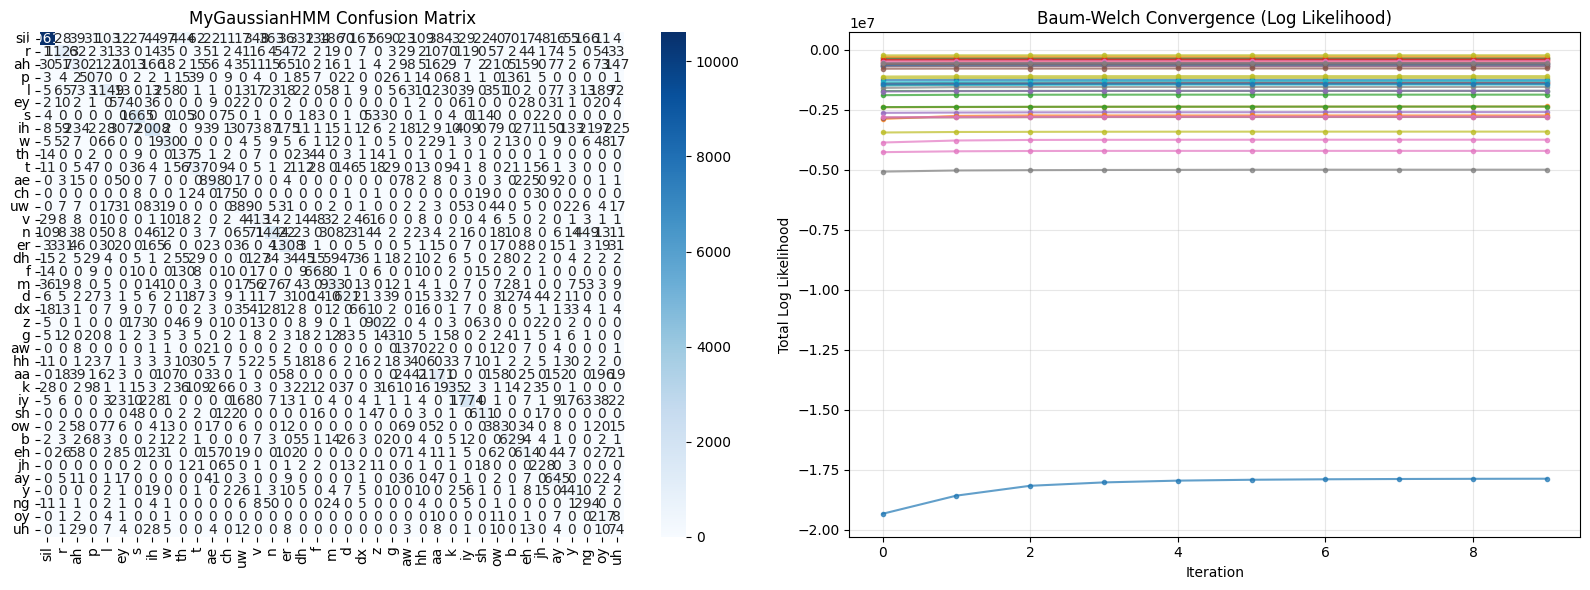

In [ ]:
# Widgets
style = {'description_width': 'initial'}
mode_widget = widgets.ToggleButtons(options=['Single Model', 'Comparison'], value='Single Model', description='Mode:')
model_widget = widgets.Dropdown(options=[('Discrete HMM','MyDiscreteHMM'), ('Gaussian HMM','MyGaussianHMM'), ('GMM-HMM','MyGMMHMM')],
                                value='MyGaussianHMM', description='Model Type:', style=style)
iter_widget = widgets.IntSlider(value=10, min=1, max=50, description='Train Iterations:', style=style)
n_states_widget = widgets.IntSlider(value=3, min=2, max=5, description='States:', style=style)
n_symbols_widget = widgets.IntSlider(value=64, min=16, max=128, step=16, description='Symbols (Discrete):', style=style)
n_mix_widget = widgets.IntSlider(value=8, min=2, max=16, description='Mixtures (GMM):', style=style)
run_button = widgets.Button(description='Run pipeline', button_style='success')
run_compare_button = widgets.Button(description='Run comparison', button_style='warning')
output = widgets.Output()

# Dynamic hyperparams
param_box = widgets.VBox([])
def update_param_box(change=None):
    name = model_widget.value
    if name == 'MyDiscreteHMM':
        param_box.children = [n_symbols_widget]
    elif name == 'MyGMMHMM':
        param_box.children = [n_mix_widget]
    elif name == 'MyGaussianHMM':
        param_box.children = []
model_widget.observe(update_param_box, names='value')
update_param_box()

config_box = widgets.VBox([])
def update_model_visibility(change=None):
    if mode_widget.value == 'Single Model':
        config_box.children = [model_widget, iter_widget, n_states_widget, param_box, run_button]
    elif mode_widget.value == 'Comparison':
        config_box.children = [iter_widget, n_states_widget, param_box, run_compare_button]
mode_widget.observe(update_model_visibility, names='value')
update_model_visibility()

def on_click_run(b):
    with output:
        output.clear_output(wait=True)
        config = {
            'model_type': model_widget.value,
            'n_iter': iter_widget.value,
            'n_states': n_states_widget.value,
            'n_symbols': n_symbols_widget.value,
            'n_mix': n_mix_widget.value
        }
    try:
        mode = mode_widget.value
        if mode == 'Single Model':
            run_pipeline(config, train_sequences, test_sequences)
        elif mode == 'Comparison':
            run_comparison(config)
    except Exception as e:
        print(f"Error running experiment: {e}")

run_button.on_click(on_click_run)

# Layout
ui = widgets.VBox([
    widgets.HTML("<h2>TIMIT HMM Control Panel</h2>"),
    mode_widget,
    config_box,
    widgets.HTML("<hr>"),
    output
])

# Display
display(ui)